####  Sistema de Predição de Doenças com Machine Learning

Este projeto tem como objetivo desenvolver um modelo de aprendizado de máquina capaz de prever doenças com base nos sintomas apresentados.

A proposta é utilizar técnicas de classificação supervisionada para auxiliar na triagem médica, oferecendo uma previsão automatizada com base em dados históricos.

Etapas do projeto:
- Análise exploratória dos dados
- Pré-processamento
- Treinamento de modelos
- Avaliação de desempenho
- Otimização
- Teste de predição

### 1 - importacoes

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2 - Importacao do dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving symptom_based_medicine_recommendation_dataset.csv to symptom_based_medicine_recommendation_dataset (2).csv


In [ ]:
df = pd.read_csv("symptom_based_medicine_recommendation_dataset.csv")
df.head()

,name,gender,age_exact,smoking,alcohol,exercise_level,diet_quality,family_history,weight_kg,height_cm,...,symptom_3,symptom_4,symptom_5,symptom_6,symptom_7,disease,recommended_medicine,secondary_medicine,reaction_occurred,reaction_name
0,Manoj Ghosh,female,8,no,no,medium,poor,yes,35,134,...,blurred_vision,chest_pain,chills,back_pain,dizziness,Diabetes,Metformin (500 mg); Glimepiride (2 mg),Metformin,yes,drowsiness
1,Karthik Pandey,other,88,yes,no,low,average,no,25,174,...,tenderness,depression,abdominal_pain,fatigue,muscle_pain,Gout,Allopurinol (300 mg); Colchicine (0.5 mg),Colchicine,yes,nausea
2,Uday Shetty,other,26,no,no,high,poor,no,55,163,...,shortness_of_breath,dizziness,fever,productive_cough,abdominal_pain,Pneumonia,Amoxicillin-clavulanate (625 mg); Azithromycin...,Ceftriaxone,yes,rash
3,Arjun Mannan,other,65,yes,no,low,poor,no,18,151,...,nocturnal_symptoms,sweating,abdominal_pain,chills,ear_pain,Asthma,Salbutamol inhaler (100 mcg); Budesonide inhal...,Salbutamol,no,none
4,Anusha Nair,other,17,no,no,low,average,no,58,174,...,fatigue,vomiting,fever,blurred_vision,insomnia,Hepatitis,Tenofovir (300 mg); Ursodeoxycholic acid (300 mg),Interferon,yes,headache


## 3- Analise exploratoria

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  2000 non-null   object 
 1   gender                2000 non-null   object 
 2   age_exact             2000 non-null   int64  
 3   smoking               2000 non-null   object 
 4   alcohol               2000 non-null   object 
 5   exercise_level        2000 non-null   object 
 6   diet_quality          2000 non-null   object 
 7   family_history        2000 non-null   object 
 8   weight_kg             2000 non-null   int64  
 9   height_cm             2000 non-null   int64  
 10  bmi                   2000 non-null   float64
 11  bp                    2000 non-null   object 
 12  blood_sugar           2000 non-null   object 
 13  heart_rate            2000 non-null   int64  
 14  cholesterol           2000 non-null   int64  
 15  symptom_1            

In [ ]:
df.isnull().sum()

,0
name,0
gender,0
age_exact,0
smoking,0
alcohol,0
exercise_level,0
diet_quality,0
family_history,0
weight_kg,0
height_cm,0


In [ ]:
df['disease'].value_counts()

,count
disease,
Gout,117
Common Cold,113
Influenza,110
Typhoid,107
Chickenpox,106
Migraine,105
Malaria,105
Hypertension,105
Dermatitis,104


## 4 - Vizualizacao da distribuicao


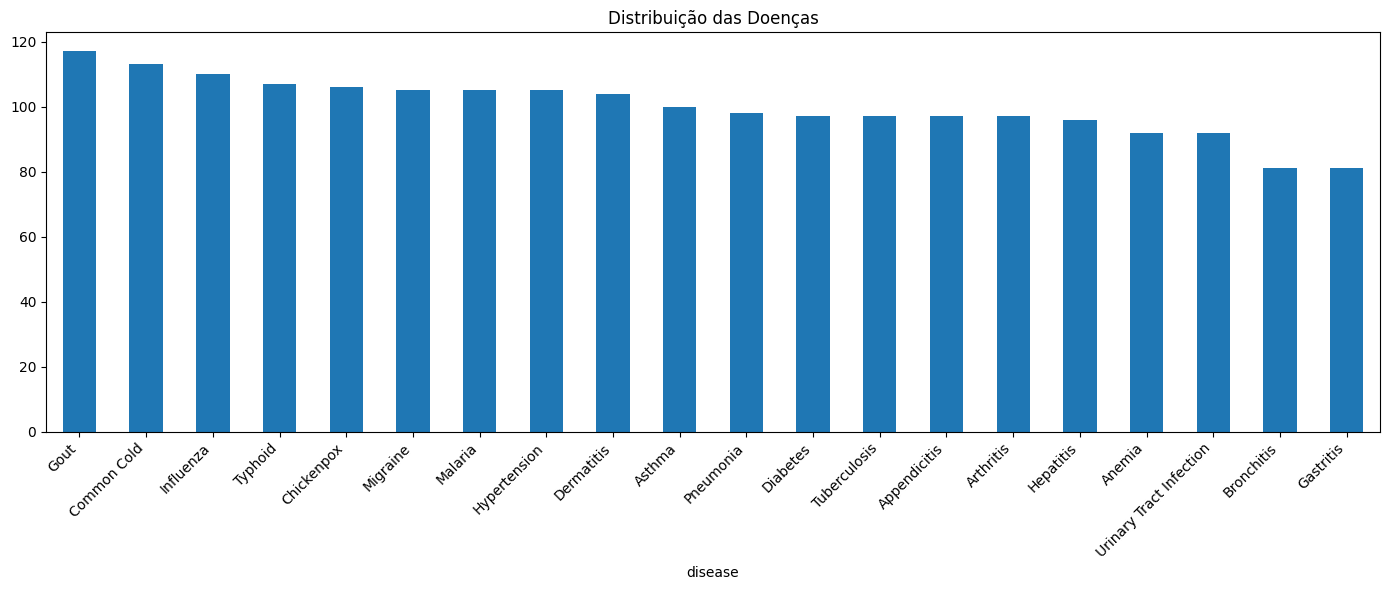

In [ ]:
plt.figure(figsize=(14,6))
df['disease'].value_counts().plot(kind='bar')

plt.xticks(rotation=45, ha='right')
plt.title("Distribuição das Doenças")

plt.tight_layout()
plt.show()

## 5 - Pre-processamento

In [ ]:
le = LabelEncoder()
df['disease'] = le.fit_transform(df['disease'])

In [ ]:
X = df.drop([  #removi colunas de string pra treinamento dos modelos
    'disease',
    'name',
    'recommended_medicine',
    'secondary_medicine',
    'reaction_name'
], axis=1)

y = df['disease']

X = pd.get_dummies(X) #converti os categoricos em numericos pra evitar de quebrar o codigo, assim eu pude treinar os modelos mesmo com dados em string

## 6 - Divisão treino/teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 7 - Treinamento dos Modelos

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.preprocessing import StandardScaler # fiz isso pra subir a acuracia do KNN, saiu de 0,04 pra 0.895

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

## 8 - Avaliacao dos modelos

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Random Forest": rf,
    "Decision Tree": dt,
    "KNN": knn
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\nModelo: {name}")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Modelo: Random Forest
Acurácia: 0.955
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        20
           3       1.00      0.91      0.95        11
           4       0.93      0.88      0.90        16
           5       0.93      1.00      0.96        26
           6       1.00      0.96      0.98        26
           7       1.00      0.92      0.96        25
           8       1.00      1.00      1.00        21
           9       0.94      1.00      0.97        16
          10       1.00      1.00      1.00        23
          11       0.86      0.90      0.88        21
          12       1.00      0.88      0.93        16
          13       0.91      1.00      0.95        20
          14       0.84      0.76      0.80        21
          15       1.00      0.93      0.97        30
          16       0.82      0.93      0.8

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### 9- Análise de Acertos do Modelo

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


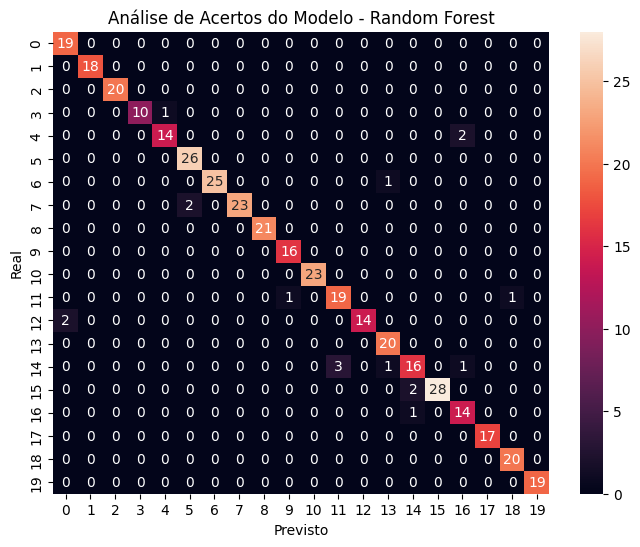

In [ ]:
from sklearn.metrics import confusion_matrix    #Essa tabela mostra onde o modelo acerta e onde ele erra.
import seaborn as sns                           #A diagonal principal representa os acertos, e como podemos ver, a maioria dos valores está concentrada nela, indicando alto desempenho.
import matplotlib.pyplot as plt                 #Os valores fora da diagonal representam erros, mostrando que algumas doenças com sintomas semelhantes podem ser confundidas.

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Análise de Acertos do Modelo - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## 10 - otimizacao

In [ ]:
from sklearn.model_selection import GridSearchCV #Foi realizada uma otimização de hiperparâmetros utilizando GridSearchCV.
from sklearn.ensemble import RandomForestClassifier #O melhor modelo encontrado utilizou 100 árvores e profundidade máxima ilimitada,
                                                     #apresentando o melhor desempenho na validação cruzada.
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Melhores parâmetros:", grid.best_params_)

Melhores parâmetros: {'max_depth': None, 'n_estimators': 100}


## 11 - teste de predicao

In [ ]:
sample = X.iloc[0].values.reshape(1, -1)
prediction = best_model.predict(sample)

print("Doença prevista:", le.inverse_transform(prediction)) #optei por deixar o nome original da doenca do .csv

Doença prevista: ['Diabetes']


##